# COMP3516 2026 Spring Group Project
## Multi-modal human activity recognition

In this task, we will utilize the OctoNet dataset developed by HKU AIoT Lab to build a multi-modal human activity recognition system. In the dataset, we use 5 activities (sitting, sleeping, walking, falling down and jumping), and we record each sample using 3 modalities: infrared array (IRA), WiFi CSI and IMU.

The training set size is 400, and the masked testing set has 63 samples.

__your sutent IDs here (3 students per group):__


### Task 1: Visualize the data (10 pt)
1. Please load one IRA sample of each class from the dataset and visualize it using inferno colormap. You could also include these images in your report, if you want.
2. Please select one CSI sample, and visualize the amplitude of the second link and the subcarrier of index 1. Look at the sample below. You need also provide the code and sample used.

![sample IRA image](output.png)
![sample CSI image](output_wifi.png)

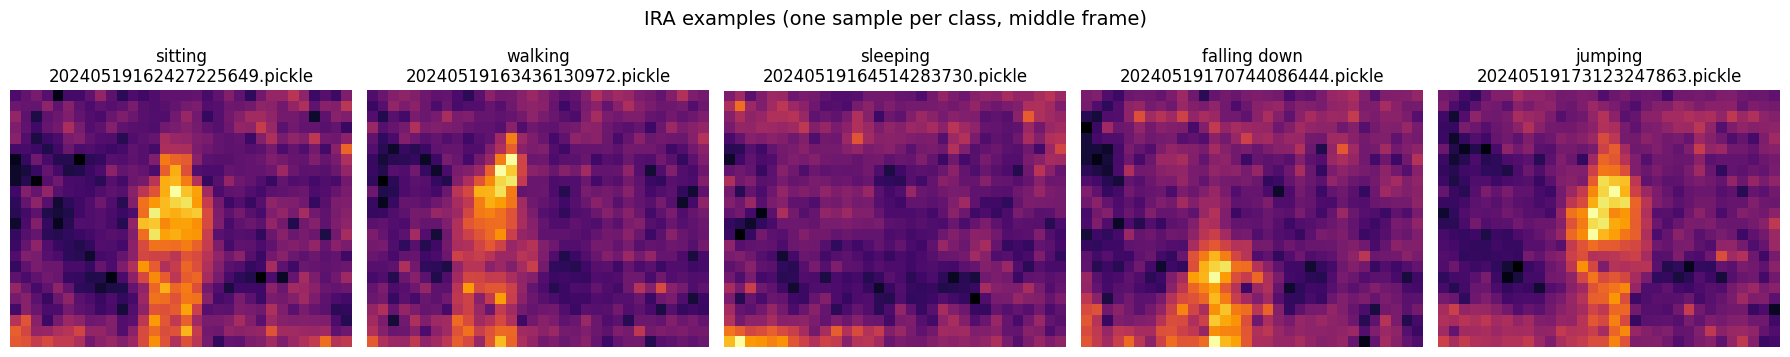

IRA samples used:
  1 - sitting: 20240519162427225649.pickle
  2 - walking: 20240519163436130972.pickle
  3 - sleeping: 20240519164514283730.pickle
  4 - falling down: 20240519170744086444.pickle
  5 - jumping: 20240519173123247863.pickle


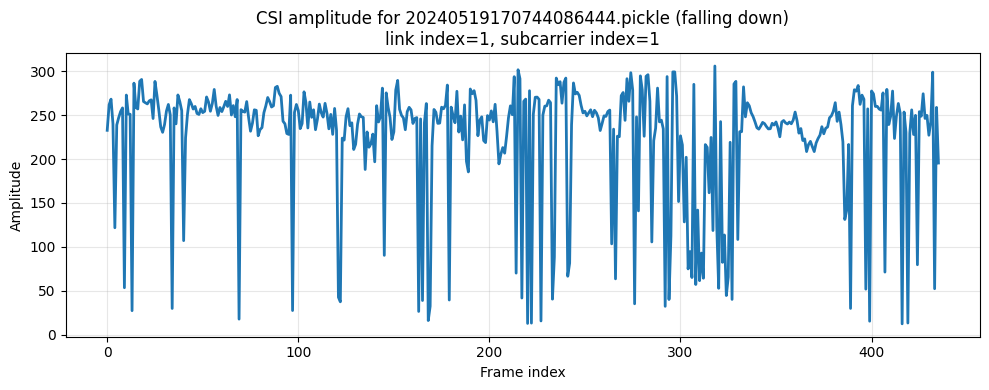

CSI sample used:
  20240519170744086444.pickle (falling down), link index=1, subcarrier index=1


In [2]:
import csv
import pickle
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATASET_PATH = Path("data_sources")
CSV_PATH = Path("activity_masked.csv")
LABEL_NAMES = {
    "1": "sitting",
    "2": "walking",
    "3": "sleeping",
    "4": "falling down",
    "5": "jumping",
}


def compat_unpickle_timestamp(value, *args):
    # Stored timestamps are metadata only for this task, so a standard datetime is enough.
    return dt.datetime.fromtimestamp(value / 1_000_000_000)


class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "pandas._libs.tslibs.timestamps" and name == "_unpickle_timestamp":
            return compat_unpickle_timestamp
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)


def load_pickle_sample(filename):
    with open(DATASET_PATH / filename, "rb") as f:
        return CompatUnpickler(f).load()


def first_valid_frames(modality_nodes):
    for node in modality_nodes:
        if node is None:
            continue
        frames = np.asarray(node.get("frames", []))
        if frames.size > 0:
            return frames
    return None


rows = []
with open(CSV_PATH, newline="") as f:
    reader = csv.DictReader(f)
    rows = [row for row in reader if row["activity_id"].strip()]

# 1) One IRA sample from each activity class, visualized with inferno.
ira_examples = {}
for row in rows:
    label = row["activity_id"].strip()
    if label in ira_examples:
        continue

    sample = load_pickle_sample(row["filename"])
    ira_frames = first_valid_frames(sample.get("modality_data", {}).get("IRA", []))
    if ira_frames is None or ira_frames.ndim != 3 or ira_frames.shape[0] == 0:
        continue

    ira_examples[label] = {
        "filename": row["filename"],
        "activity": LABEL_NAMES[label],
        "frames": ira_frames,
    }

    if len(ira_examples) == len(LABEL_NAMES):
        break

if len(ira_examples) != len(LABEL_NAMES):
    missing = sorted(set(LABEL_NAMES) - set(ira_examples))
    raise RuntimeError(f"Could not find IRA samples for labels: {missing}")

fig, axes = plt.subplots(1, len(LABEL_NAMES), figsize=(18, 4))
for ax, label in zip(axes, sorted(LABEL_NAMES, key=int)):
    example = ira_examples[label]
    frame_idx = example["frames"].shape[0] // 2  # middle frame is usually more informative than the first frame
    ax.imshow(example["frames"][frame_idx], cmap="inferno")
    ax.set_title(f"{example['activity']}\n{example['filename']}")
    ax.axis("off")

fig.suptitle("IRA examples (one sample per class, middle frame)", fontsize=14)
fig.tight_layout()
fig.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

print("IRA samples used:")
for label in sorted(LABEL_NAMES, key=int):
    example = ira_examples[label]
    print(f"  {label} - {example['activity']}: {example['filename']}")

# 2) One CSI sample: amplitude of link index 1 (second link) and subcarrier index 1 over time.
wifi_example = None
for row in rows:
    sample = load_pickle_sample(row["filename"])
    wifi_frames = first_valid_frames(sample.get("modality_data", {}).get("wifi", []))
    if wifi_frames is None or wifi_frames.ndim != 3:
        continue
    if wifi_frames.shape[1] < 2 or wifi_frames.shape[2] < 2:
        continue

    wifi_example = {
        "filename": row["filename"],
        "activity": LABEL_NAMES[row["activity_id"].strip()],
        "frames": wifi_frames,
    }
    break

if wifi_example is None:
    raise RuntimeError("Could not find a valid wifi/CSI sample with at least 2 links and 2 subcarriers.")

link_index = 1
subcarrier_index = 1
wifi_amplitude = np.abs(wifi_example["frames"][:, link_index, subcarrier_index])
time_index = np.arange(len(wifi_amplitude))

plt.figure(figsize=(10, 4))
plt.plot(time_index, wifi_amplitude, linewidth=2)
plt.title(
    f"CSI amplitude for {wifi_example['filename']} ({wifi_example['activity']})\n"
    f"link index={link_index}, subcarrier index={subcarrier_index}"
)
plt.xlabel("Frame index")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("output_wifi.png", dpi=200, bbox_inches="tight")
plt.show()

print("CSI sample used:")
print(
    f"  {wifi_example['filename']} ({wifi_example['activity']}), "
    f"link index={link_index}, subcarrier index={subcarrier_index}"
)


### Task 2: Single modality classification (40 pt)
For each modality, build a single modality classifier to recognize the 5 activities. You can choose any model architecture you like, but you need to justify your choice in the report. 

- Marking criteria: 
    - results fully reproducible (10 pt)
    - output accuracy (30 pt)
        - for each modality, highest accuracy (top1) among the class, 10pt
        - top [2 to 20%] accuracy among the class, 9pt
        - top (20% to 50%] accuracy among the class, 8pt
        - top (50% to 70%] accuracy among the class, 6pt
        - rest 30%, runnable code, 5pt

In [3]:
# Shared preprocessing for all modality models.
# This cell loads pickle files safely, cleans each modality, and aligns them onto a shared timeline.

import csv
import datetime as dt
import pickle
import random
from pathlib import Path

import numpy as np

PROJECT_DATASET_PATH = Path('data_sources')
PROJECT_CSV_PATH = Path('activity_masked.csv')
PROJECT_SEED = 42
PROJECT_MODALITIES = ('IRA', 'wifi', 'imu')
PROJECT_DEFAULT_SHAPES = {
    'IRA': (1, 24, 32),
    'wifi': (1, 2, 114),
    'imu': (1, 13, 17),
}
PROJECT_LABEL_NAMES = {
    0: 'sitting',
    1: 'walking',
    2: 'sleeping',
    3: 'falling down',
    4: 'jumping',
}


def set_project_seed(seed=PROJECT_SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception:
            pass
    except ImportError:
        pass


def compat_unpickle_timestamp(value, *args):
    return dt.datetime.fromtimestamp(value / 1_000_000_000)


class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'pandas._libs.tslibs.timestamps' and name == '_unpickle_timestamp':
            return compat_unpickle_timestamp
        if module.startswith('numpy._core'):
            module = module.replace('numpy._core', 'numpy.core', 1)
        return super().find_class(module, name)


def load_raw_pickle_sample(filename):
    with open(PROJECT_DATASET_PATH / filename, 'rb') as f:
        return CompatUnpickler(f).load()


def read_labeled_rows(csv_path=PROJECT_CSV_PATH):
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        return [row for row in reader if row['activity_id'].strip()]


def timestamp_to_ns(timestamp):
    if timestamp is None:
        return None
    if isinstance(timestamp, np.datetime64):
        return int(timestamp.astype('datetime64[ns]').astype(np.int64))
    if isinstance(timestamp, dt.datetime):
        if timestamp.tzinfo is not None:
            timestamp = timestamp.astimezone(dt.timezone.utc).replace(tzinfo=None)
        return int(timestamp.timestamp() * 1_000_000_000)
    if isinstance(timestamp, dt.date):
        combined = dt.datetime.combine(timestamp, dt.time())
        return int(combined.timestamp() * 1_000_000_000)
    if isinstance(timestamp, (np.integer, int)):
        return int(timestamp)
    if isinstance(timestamp, (np.floating, float)):
        if not np.isfinite(timestamp):
            return None
        if abs(timestamp) < 1e12:
            return int(timestamp * 1_000_000_000)
        return int(timestamp)
    if hasattr(timestamp, 'value'):
        try:
            return int(timestamp.value)
        except Exception:
            return None
    return None


def sanitize_frames(frames, modality):
    arr = np.asarray(frames)
    if arr.size == 0:
        return np.zeros(PROJECT_DEFAULT_SHAPES[modality], dtype=np.float32)
    if modality == 'wifi':
        arr = np.abs(arr)
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    if arr.ndim == len(PROJECT_DEFAULT_SHAPES[modality]) - 1:
        arr = arr[None, ...]
    return arr


def fallback_timestamps(num_frames):
    return np.arange(max(1, num_frames), dtype=np.int64)


def clean_primary_modality_node(sample, modality):
    modality_nodes = sample.get('modality_data', {}).get(modality, []) or []

    for node in modality_nodes:
        if node is None:
            continue

        frames = sanitize_frames(node.get('frames', []), modality)
        if frames.shape[0] == 0:
            continue

        raw_timestamps = list(node.get('timestamps', []))
        usable_len = min(len(raw_timestamps), frames.shape[0])

        if usable_len > 0:
            timestamps = [timestamp_to_ns(ts) for ts in raw_timestamps[:usable_len]]
            valid_mask = np.array([ts is not None for ts in timestamps], dtype=bool)
            if valid_mask.any():
                timestamps = np.asarray([ts for ts in timestamps if ts is not None], dtype=np.int64)
                frames = frames[:usable_len][valid_mask]
            else:
                timestamps = fallback_timestamps(frames.shape[0])
        else:
            timestamps = fallback_timestamps(frames.shape[0])

        if frames.shape[0] == 0:
            continue

        order = np.argsort(timestamps, kind='stable')
        timestamps = timestamps[order]
        frames = frames[order]

        _, unique_idx = np.unique(timestamps, return_index=True)
        unique_idx = np.sort(unique_idx)
        timestamps = timestamps[unique_idx]
        frames = frames[unique_idx]

        return {
            'frames': frames.astype(np.float32),
            'timestamps': timestamps.astype(np.int64),
            'valid': True,
        }

    return {
        'frames': np.zeros(PROJECT_DEFAULT_SHAPES[modality], dtype=np.float32),
        'timestamps': fallback_timestamps(1),
        'valid': False,
    }


def resample_frames_by_index(frames, target_len):
    if frames.shape[0] == target_len:
        return frames.astype(np.float32)
    indices = np.linspace(0, frames.shape[0] - 1, target_len).round().astype(int)
    return frames[indices].astype(np.float32)


def build_shared_timeline(valid_nodes, target_len):
    if len(valid_nodes) < 2:
        return None, False

    common_start = max(node['timestamps'][0] for node in valid_nodes)
    common_end = min(node['timestamps'][-1] for node in valid_nodes)

    if common_end <= common_start:
        return None, False

    if target_len == 1:
        return np.asarray([common_start], dtype=np.int64), True

    timeline = np.linspace(common_start, common_end, target_len).round().astype(np.int64)
    return timeline, True


def align_node_to_timeline(node, timeline_ns):
    timestamps = node['timestamps']
    frames = node['frames']

    insert_positions = np.searchsorted(timestamps, timeline_ns, side='left')
    insert_positions = np.clip(insert_positions, 0, len(timestamps) - 1)
    prev_positions = np.clip(insert_positions - 1, 0, len(timestamps) - 1)

    choose_prev = np.abs(timestamps[prev_positions] - timeline_ns) <= np.abs(timestamps[insert_positions] - timeline_ns)
    nearest_positions = np.where(choose_prev, prev_positions, insert_positions)

    return frames[nearest_positions].astype(np.float32)


def preprocess_sample(sample, target_len=None, modalities=PROJECT_MODALITIES):
    cleaned_nodes = {modality: clean_primary_modality_node(sample, modality) for modality in modalities}
    valid_nodes = [node for node in cleaned_nodes.values() if node['valid']]

    if target_len is None:
        valid_lengths = [node['frames'].shape[0] for node in valid_nodes if node['frames'].shape[0] > 0]
        target_len = max(1, min(valid_lengths)) if valid_lengths else 1

    shared_timeline_ns, has_shared_overlap = build_shared_timeline(valid_nodes, target_len)

    aligned_frames = {}
    for modality in modalities:
        node = cleaned_nodes[modality]
        if node['valid'] and has_shared_overlap:
            aligned_frames[modality] = align_node_to_timeline(node, shared_timeline_ns)
        elif node['valid']:
            aligned_frames[modality] = resample_frames_by_index(node['frames'], target_len)
        else:
            aligned_frames[modality] = np.zeros((target_len, *PROJECT_DEFAULT_SHAPES[modality][1:]), dtype=np.float32)

    if shared_timeline_ns is None:
        shared_timeline_ns = fallback_timestamps(target_len)

    return {
        'aligned_frames': aligned_frames,
        'timeline_ns': shared_timeline_ns.astype(np.int64),
        'has_shared_overlap': has_shared_overlap,
        'target_len': target_len,
        'available_modalities': [modality for modality, node in cleaned_nodes.items() if node['valid']],
    }


def load_preprocessed_sample(filename, target_len=None, modalities=PROJECT_MODALITIES):
    sample = load_raw_pickle_sample(filename)
    return preprocess_sample(sample, target_len=target_len, modalities=modalities)


set_project_seed(PROJECT_SEED)
print('Shared preprocessing ready for IRA, CSI, and IMU models.')


Shared preprocessing ready for IRA, CSI, and IMU models.


In [4]:
# Shared CSV export helper for model predictions on the masked rows.
# Any single-modality model can reuse this by passing a prediction function.

import csv
from collections import Counter
from pathlib import Path

CSV_ACTIVITY_NAME_BY_ID = {
    1: 'sit',
    2: 'walk',
    3: 'sleep',
    4: 'falldown',
    5: 'jump',
}


def export_masked_rows_to_labelled_csv(
    output_csv_path,
    predict_activity_id_fn,
    source_csv_path=PROJECT_CSV_PATH,
    activity_name_by_id=CSV_ACTIVITY_NAME_BY_ID,
):
    output_csv_path = Path(output_csv_path)

    with open(source_csv_path, newline='') as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames
        rows = list(reader)

    prediction_counts = Counter()
    num_predicted_rows = 0

    for row in rows:
        if row['activity_id'].strip():
            continue

        pred_activity_id = int(predict_activity_id_fn(row['filename']))
        if pred_activity_id not in activity_name_by_id:
            raise ValueError(f'Unsupported predicted activity id: {pred_activity_id}')

        row['activity_id'] = str(pred_activity_id)
        row['activity'] = activity_name_by_id[pred_activity_id]
        prediction_counts[row['activity']] += 1
        num_predicted_rows += 1

    with open(output_csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return {
        'output_csv_path': output_csv_path,
        'num_predicted_rows': num_predicted_rows,
        'prediction_counts': dict(prediction_counts),
    }


print('Shared masked-CSV export helper ready for IRA, CSI, and IMU models.')


Shared masked-CSV export helper ready for IRA, CSI, and IMU models.


Device: cuda
Labeled IRA samples: 400
Train samples: 320, Validation samples: 80
Train distribution: {'sitting': 64, 'walking': 67, 'sleeping': 62, 'falling down': 58, 'jumping': 69}
Validation distribution: {'sitting': 16, 'walking': 17, 'sleeping': 16, 'falling down': 14, 'jumping': 17}


c:\Users\User\miniconda3\envs\comp3516\lib\site-packages\torch\autograd\graph.py:829: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
c:\Users\User\miniconda3\envs\comp3516\lib\site-packages\torch\autograd\graph.py:829: UserWarning: max_pool3d_with_indices_backward_cuda does not have a deterministic imp

Epoch 01/30 | train_loss=1.5202 train_acc=0.3500 | val_loss=1.5700 val_acc=0.2000 | lr=0.000300
Epoch 02/30 | train_loss=1.3383 train_acc=0.5062 | val_loss=1.1704 val_acc=0.6250 | lr=0.000300
Epoch 03/30 | train_loss=1.1647 train_acc=0.6438 | val_loss=1.2564 val_acc=0.4625 | lr=0.000300
Epoch 04/30 | train_loss=1.0532 train_acc=0.7063 | val_loss=0.9640 val_acc=0.6375 | lr=0.000300
Epoch 05/30 | train_loss=0.9234 train_acc=0.7719 | val_loss=1.2182 val_acc=0.5625 | lr=0.000300
Epoch 06/30 | train_loss=0.8338 train_acc=0.8125 | val_loss=1.0227 val_acc=0.5500 | lr=0.000300
Epoch 07/30 | train_loss=0.7482 train_acc=0.8625 | val_loss=0.6958 val_acc=0.8375 | lr=0.000300
Epoch 08/30 | train_loss=0.6927 train_acc=0.8375 | val_loss=0.7987 val_acc=0.7250 | lr=0.000300
Epoch 09/30 | train_loss=0.6129 train_acc=0.8875 | val_loss=0.6896 val_acc=0.8250 | lr=0.000300
Epoch 10/30 | train_loss=0.5686 train_acc=0.8969 | val_loss=0.9464 val_acc=0.7000 | lr=0.000300
Epoch 11/30 | train_loss=0.5021 train_ac

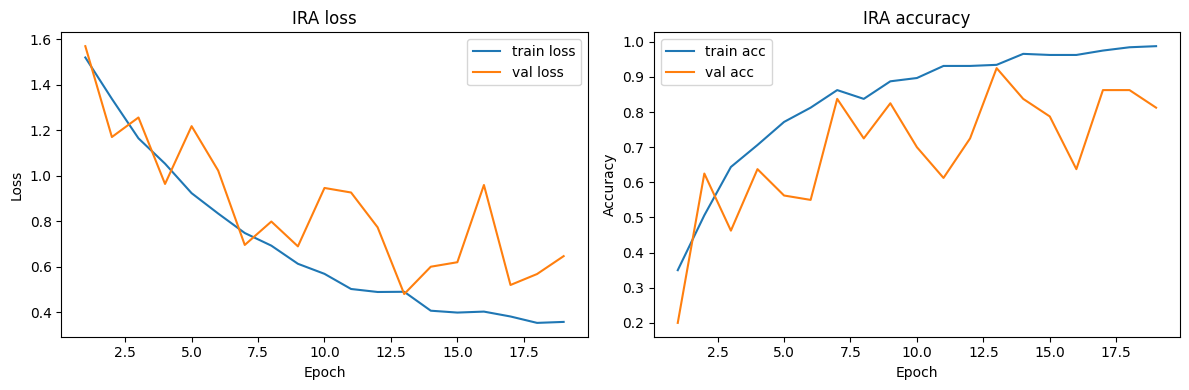

In [5]:
# IRA Modality Model
# Self-contained IRA training pipeline for Task 2.

import copy
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

required_shared_globals = (
    'load_preprocessed_sample',
    'read_labeled_rows',
    'set_project_seed',
    'PROJECT_CSV_PATH',
    'PROJECT_LABEL_NAMES',
    'PROJECT_SEED',
)
missing_shared_globals = [name for name in required_shared_globals if name not in globals()]
if missing_shared_globals:
    raise RuntimeError(
        'Run the shared preprocessing cell above before training the IRA model. '
        f'Missing: {missing_shared_globals}'
    )

IRA_CHECKPOINT_PATH = Path('ira_model_best.pt')

IRA_SEED = PROJECT_SEED
IRA_NUM_FRAMES = 24
IRA_BATCH_SIZE = 16
IRA_NUM_EPOCHS = 30
IRA_LEARNING_RATE = 3e-4
IRA_WEIGHT_DECAY = 1e-4
IRA_VAL_RATIO = 0.2
IRA_GRAD_CLIP_NORM = 1.0
IRA_EARLY_STOPPING_PATIENCE = 6

IRA_LABEL_NAMES = dict(PROJECT_LABEL_NAMES)


def normalize_ira(frames):
    mean = frames.mean()
    std = frames.std()
    return (frames - mean) / (std + 1e-6)


def stratified_split(rows, val_ratio=IRA_VAL_RATIO, seed=IRA_SEED):
    grouped_rows = defaultdict(list)
    for row in rows:
        grouped_rows[int(row['activity_id']) - 1].append(row)

    rng = random.Random(seed)
    train_rows = []
    val_rows = []
    for label in sorted(grouped_rows):
        label_rows = list(grouped_rows[label])
        rng.shuffle(label_rows)
        val_count = max(1, int(round(len(label_rows) * val_ratio)))
        val_rows.extend(label_rows[:val_count])
        train_rows.extend(label_rows[val_count:])

    rng.shuffle(train_rows)
    rng.shuffle(val_rows)
    return train_rows, val_rows


class IRADataset(Dataset):
    def __init__(self, rows, num_frames=IRA_NUM_FRAMES, augment=False):
        self.rows = rows
        self.num_frames = num_frames
        self.augment = augment

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        processed = load_preprocessed_sample(row['filename'], target_len=self.num_frames)
        ira_frames = normalize_ira(processed['aligned_frames']['IRA'])

        if self.augment:
            if random.random() < 0.5:
                ira_frames = ira_frames[:, :, ::-1].copy()
            if random.random() < 0.3:
                noise = np.random.normal(loc=0.0, scale=0.02, size=ira_frames.shape).astype(np.float32)
                ira_frames = ira_frames + noise

        ira_tensor = torch.from_numpy(ira_frames).unsqueeze(0)
        label = int(row['activity_id']) - 1
        return ira_tensor, label, row['filename']


class IRAModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2),
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2),
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def run_epoch(model, dataloader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for inputs, labels, _ in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(inputs)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), IRA_GRAD_CLIP_NORM)
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count if total_count else 0.0
    avg_acc = total_correct / total_count if total_count else 0.0
    return avg_loss, avg_acc


def label_distribution(rows):
    counts = Counter(int(row['activity_id']) - 1 for row in rows)
    return {IRA_LABEL_NAMES[label]: counts[label] for label in sorted(IRA_LABEL_NAMES)}


set_project_seed(IRA_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_rows = read_labeled_rows(PROJECT_CSV_PATH)
train_rows, val_rows = stratified_split(all_rows, val_ratio=IRA_VAL_RATIO, seed=IRA_SEED)

train_dataset = IRADataset(train_rows, num_frames=IRA_NUM_FRAMES, augment=True)
val_dataset = IRADataset(val_rows, num_frames=IRA_NUM_FRAMES, augment=False)

loader_generator = torch.Generator().manual_seed(IRA_SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=IRA_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=IRA_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model = IRAModel(num_classes=len(IRA_LABEL_NAMES)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=IRA_LEARNING_RATE, weight_decay=IRA_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

print(f'Device: {device}')
print(f'Labeled IRA samples: {len(all_rows)}')
print(f'Train samples: {len(train_rows)}, Validation samples: {len(val_rows)}')
print('Train distribution:', label_distribution(train_rows))
print('Validation distribution:', label_distribution(val_rows))

history = []
best_val_acc = 0.0
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(1, IRA_NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f'Epoch {epoch:02d}/{IRA_NUM_EPOCHS} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.6f}'
    )

    if epochs_without_improvement >= IRA_EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if best_state_dict is None:
    raise RuntimeError('IRA training did not produce a valid checkpoint.')

model.load_state_dict(best_state_dict)
torch.save(
    {
        'model_state_dict': best_state_dict,
        'config': {
            'num_frames': IRA_NUM_FRAMES,
            'batch_size': IRA_BATCH_SIZE,
            'epochs': IRA_NUM_EPOCHS,
            'learning_rate': IRA_LEARNING_RATE,
            'weight_decay': IRA_WEIGHT_DECAY,
            'grad_clip_norm': IRA_GRAD_CLIP_NORM,
            'early_stopping_patience': IRA_EARLY_STOPPING_PATIENCE,
            'seed': IRA_SEED,
        },
        'label_names': IRA_LABEL_NAMES,
        'best_val_acc': best_val_acc,
    },
    IRA_CHECKPOINT_PATH,
)

print(f'Best IRA validation accuracy: {best_val_acc:.4f}')
print(f'Saved IRA checkpoint to: {IRA_CHECKPOINT_PATH.resolve()}')

def predict_ira_activity_id(filename):
    model.eval()
    processed = load_preprocessed_sample(filename, target_len=IRA_NUM_FRAMES)
    ira_frames = normalize_ira(processed['aligned_frames']['IRA'])
    ira_tensor = torch.from_numpy(ira_frames).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(ira_tensor)
    return int(logits.argmax(dim=1).item()) + 1


ira_csv_export = export_masked_rows_to_labelled_csv(
    output_csv_path='activity_IRA_labelled.csv',
    predict_activity_id_fn=predict_ira_activity_id,
)
print(f"Predicted IRA labels for {ira_csv_export['num_predicted_rows']} previously unlabeled rows.")
print('Predicted label distribution:', ira_csv_export['prediction_counts'])
print(f"Saved labelled CSV to: {ira_csv_export['output_csv_path'].resolve()}")

epochs = [item['epoch'] for item in history]
train_accs = [item['train_acc'] for item in history]
val_accs = [item['val_acc'] for item in history]
train_losses = [item['train_loss'] for item in history]
val_losses = [item['val_loss'] for item in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label='train loss')
axes[0].plot(epochs, val_losses, label='val loss')
axes[0].set_title('IRA loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, train_accs, label='train acc')
axes[1].plot(epochs, val_accs, label='val acc')
axes[1].set_title('IRA accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


Device: cuda
Labeled CSI samples: 400
Train samples: 320, Validation samples: 80
Train distribution: {'sitting': 64, 'walking': 67, 'sleeping': 62, 'falling down': 58, 'jumping': 69}
Validation distribution: {'sitting': 16, 'walking': 17, 'sleeping': 16, 'falling down': 14, 'jumping': 17}


c:\Users\User\miniconda3\envs\comp3516\lib\site-packages\torch\autograd\graph.py:829: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01/40 | train_loss=1.4678 train_acc=0.3625 | val_loss=1.4011 val_acc=0.3875 | lr=0.000799
Epoch 02/40 | train_loss=1.0805 train_acc=0.5938 | val_loss=1.2747 val_acc=0.5750 | lr=0.000795
Epoch 03/40 | train_loss=0.8971 train_acc=0.6531 | val_loss=1.9942 val_acc=0.4875 | lr=0.000790
Epoch 04/40 | train_loss=0.8164 train_acc=0.7031 | val_loss=0.9380 val_acc=0.6250 | lr=0.000782
Epoch 05/40 | train_loss=0.6738 train_acc=0.7781 | val_loss=1.4278 val_acc=0.6125 | lr=0.000771
Epoch 06/40 | train_loss=0.5979 train_acc=0.7937 | val_loss=2.4363 val_acc=0.4750 | lr=0.000759
Epoch 07/40 | train_loss=0.5368 train_acc=0.8281 | val_loss=2.0606 val_acc=0.4375 | lr=0.000745
Epoch 08/40 | train_loss=0.4289 train_acc=0.8812 | val_loss=1.9328 val_acc=0.5000 | lr=0.000728
Epoch 09/40 | train_loss=0.3732 train_acc=0.8938 | val_loss=1.0788 val_acc=0.6625 | lr=0.000710
Epoch 10/40 | train_loss=0.3508 train_acc=0.9125 | val_loss=1.0201 val_acc=0.6625 | lr=0.000690
Epoch 11/40 | train_loss=0.2994 train_ac

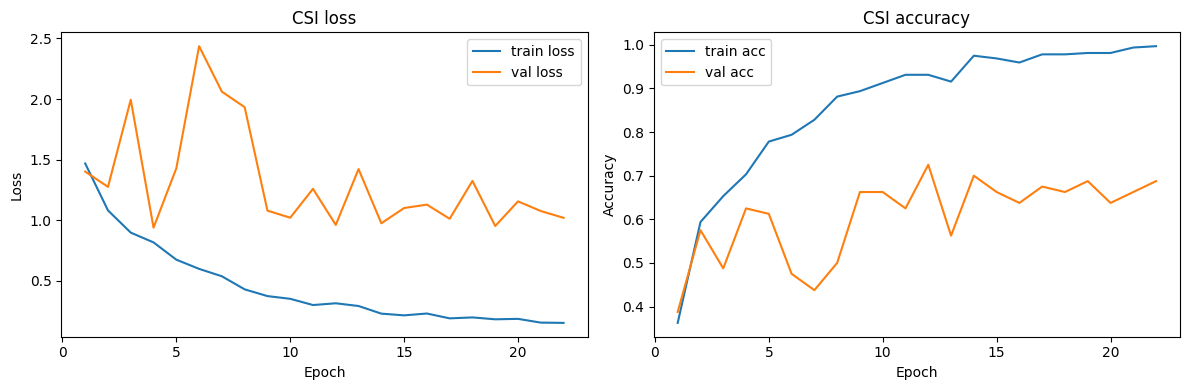

In [6]:
# CSI Modality Model
# Refined single-modality CSI training pipeline.

import copy
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

required_shared_globals = (
    'load_preprocessed_sample',
    'read_labeled_rows',
    'set_project_seed',
    'export_masked_rows_to_labelled_csv',
    'PROJECT_CSV_PATH',
    'PROJECT_LABEL_NAMES',
    'PROJECT_SEED',
)
missing_shared_globals = [name for name in required_shared_globals if name not in globals()]
if missing_shared_globals:
    raise RuntimeError(
        'Run the shared preprocessing/export cells above before training the CSI model. '
        f'Missing: {missing_shared_globals}'
    )

CSI_CHECKPOINT_PATH = Path('csi_model_best.pt')
CSI_SEED = PROJECT_SEED
CSI_NUM_FRAMES = 48
CSI_BATCH_SIZE = 16
CSI_NUM_EPOCHS = 40
CSI_LEARNING_RATE = 8e-4
CSI_MIN_LEARNING_RATE = 5e-5
CSI_WEIGHT_DECAY = 2e-4
CSI_VAL_RATIO = 0.2
CSI_GRAD_CLIP_NORM = 1.0
CSI_EARLY_STOPPING_PATIENCE = 10
CSI_LABEL_SMOOTHING = 0.02
CSI_INPUT_CHANNELS = 4
CSI_NOISE_STD = 0.01
CSI_MAX_TIME_SHIFT = 3
CSI_MAX_TIME_MASK = 6
CSI_MAX_FREQ_MASK = 12
CSI_LABEL_NAMES = dict(PROJECT_LABEL_NAMES)


def normalize_csi(frames):
    frames = np.nan_to_num(frames.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    mean = frames.mean(axis=0, keepdims=True)
    std = frames.std(axis=0, keepdims=True)
    normalized = (frames - mean) / (std + 1e-6)
    return np.clip(normalized, -5.0, 5.0)


def build_csi_features(frames):
    delta = np.diff(frames, axis=0, prepend=frames[:1])
    delta_mean = delta.mean(axis=0, keepdims=True)
    delta_std = delta.std(axis=0, keepdims=True)
    delta = (delta - delta_mean) / (delta_std + 1e-6)
    combined = np.concatenate((frames, delta), axis=1)
    return np.ascontiguousarray(np.transpose(combined, (1, 0, 2)).astype(np.float32))


def stratified_split(rows, val_ratio=CSI_VAL_RATIO, seed=CSI_SEED):
    grouped_rows = defaultdict(list)
    for row in rows:
        grouped_rows[int(row['activity_id']) - 1].append(row)

    rng = random.Random(seed)
    train_rows = []
    val_rows = []
    for label in sorted(grouped_rows):
        label_rows = list(grouped_rows[label])
        rng.shuffle(label_rows)
        val_count = max(1, int(round(len(label_rows) * val_ratio)))
        val_rows.extend(label_rows[:val_count])
        train_rows.extend(label_rows[val_count:])

    rng.shuffle(train_rows)
    rng.shuffle(val_rows)
    return train_rows, val_rows


class CSIDataset(Dataset):
    def __init__(self, rows, num_frames=CSI_NUM_FRAMES, augment=False):
        self.rows = rows
        self.num_frames = num_frames
        self.augment = augment

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        processed = load_preprocessed_sample(row['filename'], target_len=self.num_frames)
        csi_frames = normalize_csi(processed['aligned_frames']['wifi'])

        if self.augment:
            if random.random() < 0.7:
                shift = random.randint(-CSI_MAX_TIME_SHIFT, CSI_MAX_TIME_SHIFT)
                if shift:
                    csi_frames = np.roll(csi_frames, shift=shift, axis=0)
            if random.random() < 0.5:
                noise = np.random.normal(0.0, CSI_NOISE_STD, size=csi_frames.shape).astype(np.float32)
                csi_frames = csi_frames + noise
            if random.random() < 0.4:
                mask_width = random.randint(2, CSI_MAX_TIME_MASK)
                mask_start = random.randint(0, max(0, self.num_frames - mask_width))
                csi_frames[mask_start:mask_start + mask_width] = 0.0
            if random.random() < 0.35:
                freq_bins = csi_frames.shape[-1]
                mask_width = random.randint(4, CSI_MAX_FREQ_MASK)
                mask_start = random.randint(0, max(0, freq_bins - mask_width))
                csi_frames[:, :, mask_start:mask_start + mask_width] = 0.0

        csi_tensor = torch.from_numpy(build_csi_features(csi_frames))
        label = int(row['activity_id']) - 1
        return csi_tensor, label, row['filename']


class CSIModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(CSI_INPUT_CHANNELS, 32, kernel_size=(5, 7), padding=(2, 3), bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2), bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 96, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(96),
            nn.GELU(),
            nn.Conv2d(96, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(128, 192, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(192),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((3, 6)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.LazyLinear(256),
            nn.GELU(),
            nn.Dropout(p=0.20),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def run_csi_epoch(model, dataloader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for inputs, labels, _ in dataloader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(inputs)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CSI_GRAD_CLIP_NORM)
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count if total_count else 0.0
    avg_acc = total_correct / total_count if total_count else 0.0
    return avg_loss, avg_acc


def csi_label_distribution(rows):
    counts = Counter(int(row['activity_id']) - 1 for row in rows)
    return {CSI_LABEL_NAMES[label]: counts[label] for label in sorted(CSI_LABEL_NAMES)}


set_project_seed(CSI_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_rows = read_labeled_rows(PROJECT_CSV_PATH)
train_rows, val_rows = stratified_split(all_rows, val_ratio=CSI_VAL_RATIO, seed=CSI_SEED)

train_dataset = CSIDataset(train_rows, num_frames=CSI_NUM_FRAMES, augment=True)
val_dataset = CSIDataset(val_rows, num_frames=CSI_NUM_FRAMES, augment=False)

loader_generator = torch.Generator().manual_seed(CSI_SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=CSI_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CSI_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model = CSIModel(num_classes=len(CSI_LABEL_NAMES)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=CSI_LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=CSI_LEARNING_RATE, weight_decay=CSI_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CSI_NUM_EPOCHS,
    eta_min=CSI_MIN_LEARNING_RATE,
)

print(f'Device: {device}')
print(f'Labeled CSI samples: {len(all_rows)}')
print(f'Train samples: {len(train_rows)}, Validation samples: {len(val_rows)}')
print('Train distribution:', csi_label_distribution(train_rows))
print('Validation distribution:', csi_label_distribution(val_rows))

history = []
best_val_acc = -1.0
best_val_loss = float('inf')
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(1, CSI_NUM_EPOCHS + 1):
    train_loss, train_acc = run_csi_epoch(model, train_loader, criterion, device, optimizer=optimizer)
    val_loss, val_acc = run_csi_epoch(model, val_loader, criterion, device)
    scheduler.step()

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })

    improved = (val_acc > best_val_acc) or (
        np.isclose(val_acc, best_val_acc) and val_loss < best_val_loss
    )
    if improved:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f'Epoch {epoch:02d}/{CSI_NUM_EPOCHS} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.6f}'
    )

    if epochs_without_improvement >= CSI_EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if best_state_dict is None:
    raise RuntimeError('CSI training did not produce a valid checkpoint.')

model.load_state_dict(best_state_dict)
torch.save(
    {
        'model_state_dict': best_state_dict,
        'config': {
            'num_frames': CSI_NUM_FRAMES,
            'batch_size': CSI_BATCH_SIZE,
            'epochs': CSI_NUM_EPOCHS,
            'learning_rate': CSI_LEARNING_RATE,
            'min_learning_rate': CSI_MIN_LEARNING_RATE,
            'weight_decay': CSI_WEIGHT_DECAY,
            'grad_clip_norm': CSI_GRAD_CLIP_NORM,
            'early_stopping_patience': CSI_EARLY_STOPPING_PATIENCE,
            'label_smoothing': CSI_LABEL_SMOOTHING,
            'input_channels': CSI_INPUT_CHANNELS,
            'seed': CSI_SEED,
        },
        'label_names': CSI_LABEL_NAMES,
        'best_val_acc': best_val_acc,
        'best_val_loss': best_val_loss,
    },
    CSI_CHECKPOINT_PATH,
)

print(f'Best CSI validation accuracy: {best_val_acc:.4f}')
print(f'Saved CSI checkpoint to: {CSI_CHECKPOINT_PATH.resolve()}')


def predict_csi_activity_id(filename):
    model.eval()
    processed = load_preprocessed_sample(filename, target_len=CSI_NUM_FRAMES)
    csi_frames = normalize_csi(processed['aligned_frames']['wifi'])
    csi_tensor = torch.from_numpy(build_csi_features(csi_frames)).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(csi_tensor)
    return int(logits.argmax(dim=1).item()) + 1


csi_csv_export = export_masked_rows_to_labelled_csv(
    output_csv_path='activity_CSI_labelled.csv',
    predict_activity_id_fn=predict_csi_activity_id,
)
print(f"Predicted CSI labels for {csi_csv_export['num_predicted_rows']} previously unlabeled rows.")
print('Predicted label distribution:', csi_csv_export['prediction_counts'])
print(f"Saved labelled CSV to: {csi_csv_export['output_csv_path'].resolve()}")

epochs = [item['epoch'] for item in history]
train_accs = [item['train_acc'] for item in history]
val_accs = [item['val_acc'] for item in history]
train_losses = [item['train_loss'] for item in history]
val_losses = [item['val_loss'] for item in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label='train loss')
axes[0].plot(epochs, val_losses, label='val loss')
axes[0].set_title('CSI loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, train_accs, label='train acc')
axes[1].plot(epochs, val_accs, label='val acc')
axes[1].set_title('CSI accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


Device: cuda
Labeled IMU samples: 400
Train samples: 320, Validation samples: 80
Train distribution: {'sitting': 64, 'walking': 67, 'sleeping': 62, 'falling down': 58, 'jumping': 69}
Validation distribution: {'sitting': 16, 'walking': 17, 'sleeping': 16, 'falling down': 14, 'jumping': 17}


c:\Users\User\miniconda3\envs\comp3516\lib\site-packages\torch\autograd\graph.py:829: UserWarning: adaptive_avg_pool3d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01/40 | train_loss=1.3540 train_acc=0.4719 | val_loss=0.7546 val_acc=0.7500 | lr=0.000599
Epoch 02/40 | train_loss=0.7546 train_acc=0.7469 | val_loss=2.6075 val_acc=0.4500 | lr=0.000597
Epoch 03/40 | train_loss=0.4675 train_acc=0.8750 | val_loss=1.8650 val_acc=0.4875 | lr=0.000592
Epoch 04/40 | train_loss=0.3567 train_acc=0.9281 | val_loss=0.3015 val_acc=0.9500 | lr=0.000587
Epoch 05/40 | train_loss=0.3057 train_acc=0.9594 | val_loss=0.6868 val_acc=0.8125 | lr=0.000579
Epoch 06/40 | train_loss=0.2623 train_acc=0.9688 | val_loss=0.4439 val_acc=0.9250 | lr=0.000570
Epoch 07/40 | train_loss=0.2399 train_acc=0.9750 | val_loss=0.2282 val_acc=0.9750 | lr=0.000559
Epoch 08/40 | train_loss=0.2082 train_acc=0.9875 | val_loss=0.3177 val_acc=0.9375 | lr=0.000547
Epoch 09/40 | train_loss=0.1988 train_acc=0.9906 | val_loss=0.2814 val_acc=0.9750 | lr=0.000534
Epoch 10/40 | train_loss=0.1969 train_acc=0.9906 | val_loss=0.7269 val_acc=0.7500 | lr=0.000519
Epoch 11/40 | train_loss=0.1841 train_ac

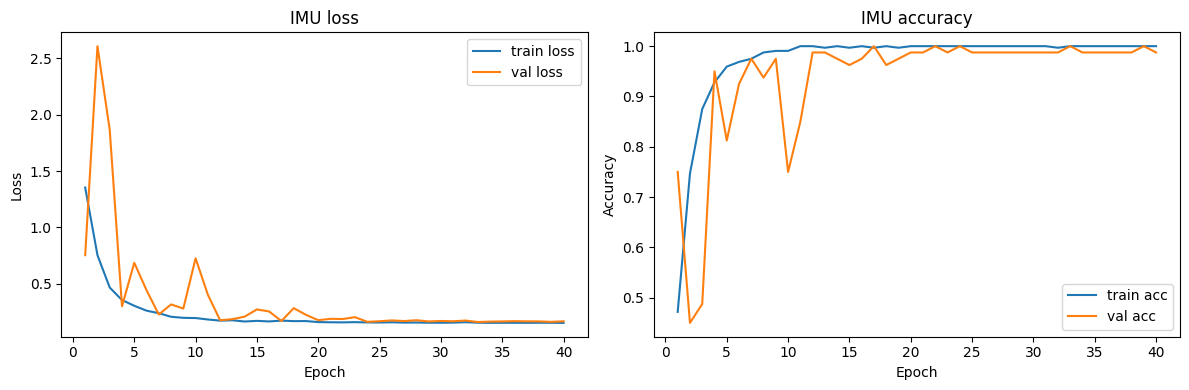

In [12]:
# IMU Modality Model
# Self-contained IMU single-modality training pipeline.

import copy
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

required_shared_globals = (
    'load_preprocessed_sample',
    'read_labeled_rows',
    'set_project_seed',
    'export_masked_rows_to_labelled_csv',
    'PROJECT_CSV_PATH',
    'PROJECT_LABEL_NAMES',
    'PROJECT_SEED',
)
missing_shared_globals = [name for name in required_shared_globals if name not in globals()]
if missing_shared_globals:
    raise RuntimeError(
        'Run the shared preprocessing/export cells above before training the IMU model. '
        f'Missing: {missing_shared_globals}'
    )

IMU_CHECKPOINT_PATH = Path('imu_model_best.pt')
IMU_SEED = PROJECT_SEED
IMU_NUM_FRAMES = 64
IMU_BATCH_SIZE = 16
IMU_NUM_EPOCHS = 40
IMU_LEARNING_RATE = 6e-4
IMU_MIN_LEARNING_RATE = 5e-5
IMU_WEIGHT_DECAY = 2e-4
IMU_VAL_RATIO = 0.2
IMU_GRAD_CLIP_NORM = 1.0
IMU_EARLY_STOPPING_PATIENCE = 10
IMU_LABEL_SMOOTHING = 0.03
IMU_INPUT_CHANNELS = 2
IMU_NOISE_STD = 0.01
IMU_MAX_TIME_SHIFT = 4
IMU_MAX_TIME_MASK = 8
IMU_LABEL_NAMES = dict(PROJECT_LABEL_NAMES)


def normalize_imu(frames):
    frames = np.nan_to_num(frames.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    mean = frames.mean(axis=0, keepdims=True)
    std = frames.std(axis=0, keepdims=True)
    normalized = (frames - mean) / (std + 1e-6)
    return np.clip(normalized, -5.0, 5.0)


def build_imu_features(frames):
    delta = np.diff(frames, axis=0, prepend=frames[:1])
    delta_mean = delta.mean(axis=0, keepdims=True)
    delta_std = delta.std(axis=0, keepdims=True)
    delta = (delta - delta_mean) / (delta_std + 1e-6)
    stacked = np.stack((frames, delta), axis=0)
    return np.ascontiguousarray(stacked.astype(np.float32))


def stratified_split(rows, val_ratio=IMU_VAL_RATIO, seed=IMU_SEED):
    grouped_rows = defaultdict(list)
    for row in rows:
        grouped_rows[int(row['activity_id']) - 1].append(row)

    rng = random.Random(seed)
    train_rows = []
    val_rows = []
    for label in sorted(grouped_rows):
        label_rows = list(grouped_rows[label])
        rng.shuffle(label_rows)
        val_count = max(1, int(round(len(label_rows) * val_ratio)))
        val_rows.extend(label_rows[:val_count])
        train_rows.extend(label_rows[val_count:])

    rng.shuffle(train_rows)
    rng.shuffle(val_rows)
    return train_rows, val_rows


class IMUDataset(Dataset):
    def __init__(self, rows, num_frames=IMU_NUM_FRAMES, augment=False):
        self.rows = rows
        self.num_frames = num_frames
        self.augment = augment

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        processed = load_preprocessed_sample(row['filename'], target_len=self.num_frames)
        imu_frames = normalize_imu(processed['aligned_frames']['imu'])

        if self.augment:
            if random.random() < 0.7:
                shift = random.randint(-IMU_MAX_TIME_SHIFT, IMU_MAX_TIME_SHIFT)
                if shift:
                    imu_frames = np.roll(imu_frames, shift=shift, axis=0)
            if random.random() < 0.5:
                noise = np.random.normal(0.0, IMU_NOISE_STD, size=imu_frames.shape).astype(np.float32)
                imu_frames = imu_frames + noise
            if random.random() < 0.35:
                scale = np.random.uniform(0.9, 1.1, size=(1, imu_frames.shape[1], 1)).astype(np.float32)
                imu_frames = imu_frames * scale
            if random.random() < 0.35:
                mask_width = random.randint(2, IMU_MAX_TIME_MASK)
                mask_start = random.randint(0, max(0, self.num_frames - mask_width))
                imu_frames[mask_start:mask_start + mask_width] = 0.0
            if random.random() < 0.25:
                joint = random.randint(0, imu_frames.shape[-1] - 1)
                imu_frames[:, :, joint] = 0.0

        imu_tensor = torch.from_numpy(build_imu_features(imu_frames))
        label = int(row['activity_id']) - 1
        return imu_tensor, label, row['filename']


class IMUModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(IMU_INPUT_CHANNELS, 32, kernel_size=(5, 3, 3), padding=(2, 1, 1), bias=False),
            nn.BatchNorm3d(32),
            nn.GELU(),
            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=1, bias=False),
            nn.BatchNorm3d(64),
            nn.GELU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
            nn.Conv3d(64, 96, kernel_size=(3, 3, 3), padding=1, bias=False),
            nn.BatchNorm3d(96),
            nn.GELU(),
            nn.Conv3d(96, 128, kernel_size=(3, 3, 3), padding=1, bias=False),
            nn.BatchNorm3d(128),
            nn.GELU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
            nn.Conv3d(128, 192, kernel_size=(3, 3, 3), padding=1, bias=False),
            nn.BatchNorm3d(192),
            nn.GELU(),
            nn.AdaptiveAvgPool3d((4, 3, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.LazyLinear(256),
            nn.GELU(),
            nn.Dropout(p=0.20),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def run_imu_epoch(model, dataloader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for inputs, labels, _ in dataloader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(inputs)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), IMU_GRAD_CLIP_NORM)
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count if total_count else 0.0
    avg_acc = total_correct / total_count if total_count else 0.0
    return avg_loss, avg_acc


def imu_label_distribution(rows):
    counts = Counter(int(row['activity_id']) - 1 for row in rows)
    return {IMU_LABEL_NAMES[label]: counts[label] for label in sorted(IMU_LABEL_NAMES)}


set_project_seed(IMU_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_rows = read_labeled_rows(PROJECT_CSV_PATH)
train_rows, val_rows = stratified_split(all_rows, val_ratio=IMU_VAL_RATIO, seed=IMU_SEED)

train_dataset = IMUDataset(train_rows, num_frames=IMU_NUM_FRAMES, augment=True)
val_dataset = IMUDataset(val_rows, num_frames=IMU_NUM_FRAMES, augment=False)

loader_generator = torch.Generator().manual_seed(IMU_SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=IMU_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=IMU_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model = IMUModel(num_classes=len(IMU_LABEL_NAMES)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=IMU_LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=IMU_LEARNING_RATE, weight_decay=IMU_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=IMU_NUM_EPOCHS,
    eta_min=IMU_MIN_LEARNING_RATE,
)

print(f'Device: {device}')
print(f'Labeled IMU samples: {len(all_rows)}')
print(f'Train samples: {len(train_rows)}, Validation samples: {len(val_rows)}')
print('Train distribution:', imu_label_distribution(train_rows))
print('Validation distribution:', imu_label_distribution(val_rows))

history = []
best_val_acc = -1.0
best_val_loss = float('inf')
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(1, IMU_NUM_EPOCHS + 1):
    train_loss, train_acc = run_imu_epoch(model, train_loader, criterion, device, optimizer=optimizer)
    val_loss, val_acc = run_imu_epoch(model, val_loader, criterion, device)
    scheduler.step()

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })

    improved = (val_acc > best_val_acc) or (
        np.isclose(val_acc, best_val_acc) and val_loss < best_val_loss
    )
    if improved:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f'Epoch {epoch:02d}/{IMU_NUM_EPOCHS} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.6f}'
    )

    if epochs_without_improvement >= IMU_EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if best_state_dict is None:
    raise RuntimeError('IMU training did not produce a valid checkpoint.')

model.load_state_dict(best_state_dict)
torch.save(
    {
        'model_state_dict': best_state_dict,
        'config': {
            'num_frames': IMU_NUM_FRAMES,
            'batch_size': IMU_BATCH_SIZE,
            'epochs': IMU_NUM_EPOCHS,
            'learning_rate': IMU_LEARNING_RATE,
            'min_learning_rate': IMU_MIN_LEARNING_RATE,
            'weight_decay': IMU_WEIGHT_DECAY,
            'grad_clip_norm': IMU_GRAD_CLIP_NORM,
            'early_stopping_patience': IMU_EARLY_STOPPING_PATIENCE,
            'label_smoothing': IMU_LABEL_SMOOTHING,
            'input_channels': IMU_INPUT_CHANNELS,
            'seed': IMU_SEED,
        },
        'label_names': IMU_LABEL_NAMES,
        'best_val_acc': best_val_acc,
        'best_val_loss': best_val_loss,
    },
    IMU_CHECKPOINT_PATH,
)

print(f'Best IMU validation accuracy: {best_val_acc:.4f}')
print(f'Saved IMU checkpoint to: {IMU_CHECKPOINT_PATH.resolve()}')


def predict_imu_activity_id(filename):
    model.eval()
    processed = load_preprocessed_sample(filename, target_len=IMU_NUM_FRAMES)
    imu_frames = normalize_imu(processed['aligned_frames']['imu'])
    imu_tensor = torch.from_numpy(build_imu_features(imu_frames)).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(imu_tensor)
    return int(logits.argmax(dim=1).item()) + 1


imu_csv_export = export_masked_rows_to_labelled_csv(
    output_csv_path='activity_IMU_labelled.csv',
    predict_activity_id_fn=predict_imu_activity_id,
)
print(f"Predicted IMU labels for {imu_csv_export['num_predicted_rows']} previously unlabeled rows.")
print('Predicted label distribution:', imu_csv_export['prediction_counts'])
print(f"Saved labelled CSV to: {imu_csv_export['output_csv_path'].resolve()}")

epochs = [item['epoch'] for item in history]
train_accs = [item['train_acc'] for item in history]
val_accs = [item['val_acc'] for item in history]
train_losses = [item['train_loss'] for item in history]
val_losses = [item['val_loss'] for item in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label='train loss')
axes[0].plot(epochs, val_losses, label='val loss')
axes[0].set_title('IMU loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, train_accs, label='train acc')
axes[1].plot(epochs, val_accs, label='val acc')
axes[1].set_title('IMU accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### Task 3: Multi modality classification (10 pt)
Build a multi modality classifier to recognize the 5 activities.

- Marking criteria: 
    - Performance improvement over your group's best single modality classifiers (7 pt)
    - Performance improvement over your group's best single modality classifiers by at least 10% (10 pt)

### Task 4: Report (40 pt)
Write a report of around 4 pages about your findings, runtime and results. Use the same latex template as in the individual project. Put down the group members' name, student ID and email in the report.

In the report, include all your processing steps (include the AI workflows), as well as the GenAI declaration. Introduce the contribution of each group member in the report. 

- Marking criteria: 
    - Clarity of the report (10 pt)
    - Justification of the model architecture choices (10 pt)
    - Runtime, results, and analysis (10 pt)
    - Processing pipelines, AI workflows, etc (10 pt)

## Submission requirements:
__Pack the following materials into a zip file:__
1. this jupyter notebook with required updates
2. all your code and trained checkpoints
3. the predicted csv with the same format as the training csv provided. Specifically, we use such a mapping for the activity labels:
    ```
        - 1: sitting
        - 2: walking
        - 3: sleeping
        - 4: falling down
        - 5: jumping
    ```
    The csv we provide contains 3 columns, filename,activity,activity_id. For the masked test set, the last two columns are blank. You should fill in the blank fields in the csv provided with your predictions, and submit the csv file.
4. the report
5. a short README.md file to the code structure and important steps to reproduce your results. You should make sure that your code is compatible with the provided data files and metadata. Include the library requirements if you use any additional libraries, and indicate this in the README.md file.

Each group only need to submit one copy. 

## a simple code illustration
__pay attention to the collating, in real world applications, the measurements are never perfectly aligned. You do not need to exactly fix the logic here, but the frame lengths may vary so you need to choose a suitable strategy to get a consistent input.__
You typically do not need to pad an empty segment since we already cleaned the data, but if you need to do so, you can refer to the code here.

```python
default_shapes = {
    'IRA': (T, 24, 32), # Time_frames, H, W
    'wifi': (T, 2, 114), # Time_frame, links, subcarriers
    'imu': (T, 13, 17), # Time_frame, 13 axes, 17 IMU nodes on joints
}
```

In [8]:
dataset_path = "data_sources"
dataset_csv = "activity_masked.csv"

import os
import csv
import random
import pickle
import datetime as dt
import numpy as np
import torch
from pathlib import Path

SEED = 42

def set_global_seed(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

set_global_seed(SEED)

def compat_unpickle_timestamp(value, *args):
    return dt.datetime.fromtimestamp(value / 1_000_000_000)


class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "pandas._libs.tslibs.timestamps" and name == "_unpickle_timestamp":
            return compat_unpickle_timestamp
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)

from torch.utils.data import dataset
class sample_dataset(dataset.Dataset):
    def __init__(self, dataset_path, read_len=None, dataset_csv=dataset_csv):
        self.dataset_path = Path(dataset_path)
        self.csv_path = dataset_csv
        self.read_csv(read_len)

    def read_csv(self, read_len=None):
        self.samples = []
        with open(self.csv_path, 'r', newline='') as f:
            reader = csv.reader(f)
            next(reader, None)  # skip header
            for row in reader:
                if len(row) < 3:
                    continue
                raw_id = (row[2] or '').strip().lower()
                if raw_id in ('', 'nan'):
                    continue
                self.samples.append(row)
        if read_len is not None and read_len < len(self.samples):
            selected_indices = random.sample(range(len(self.samples)), read_len)
            self.samples = [self.samples[i] for i in selected_indices]

    # Need to handle missing modalities and frames by padding with zeros to ensure consistent shapes for batching
    def _pad_or_fill_frames(self, frames, default_shape, use_abs=False):
        arr = np.asarray(frames)
        if arr.size == 0:
            return np.zeros(default_shape, dtype=np.float32)
        if use_abs:
            arr = np.abs(arr)
        return arr.astype(np.float32)

    def _normalize_sample(self, data_dict):
        # pad or fill missing modalities and frames with zeros
        modality_data = data_dict.get('modality_data', {})
        default_shapes = {
            'IRA': (1, 24, 32), # Time_frames, H, W
            'wifi': (1, 2, 114), # Time_frame, links, subcarriers
            'imu': (1, 13, 17), # Time_frame, 13 axes, 17 IMU nodes on joints
        }

        for modality, default_shape in default_shapes.items():
            node_list = modality_data.get(modality)
            if not node_list:
                modality_data[modality] = [{'frames': np.zeros(default_shape, dtype=np.float32)}]
                continue

            normalized_nodes = []
            for node_item in node_list:
                if node_item is None:
                    normalized_nodes.append({'frames': np.zeros(default_shape, dtype=np.float32)})
                    continue

                normalized_node = dict(node_item)
                normalized_node['frames'] = self._pad_or_fill_frames(
                    node_item.get('frames', []),
                    default_shape,
                    use_abs=(modality == 'wifi'),
                )
                normalized_nodes.append(normalized_node)

            modality_data[modality] = normalized_nodes

        data_dict['modality_data'] = modality_data
        return data_dict

    @staticmethod
    def collate_fn(batch):
        # Minimal batch-time padding over time dimension for IRA/wifi/imu
        # while preserving original sample keys/metadata
        modalities = ('IRA', 'wifi', 'imu')
        default_shapes = {
            'IRA': (1, 24, 32),
            'wifi': (1, 2, 114), # note: wifi has two receiving antennas, so 2 channels here
            'imu': (1, 13, 17),
        }

        raw_samples, labels = zip(*batch)
        samples = [dict(s) for s in raw_samples]

        per_modality = {m: [] for m in modalities}
        max_time = {m: 1 for m in modalities}

        for sample in samples:
            modality_data = sample.get('modality_data', {})
            for modality in modalities:
                node_list = modality_data.get(modality, [])
                if not node_list or node_list[0] is None:
                    frames = np.zeros(default_shapes[modality], dtype=np.float32)
                else:
                    frames = np.asarray(node_list[0].get('frames', []))
                    if frames.size == 0:
                        frames = np.zeros(default_shapes[modality], dtype=np.float32)
                    else:
                        if modality == 'wifi':
                            frames = np.abs(frames)
                        frames = frames.astype(np.float32)

                per_modality[modality].append(frames)
                max_time[modality] = max(max_time[modality], frames.shape[0])

        batch_modality_data = {}
        for modality in modalities:
            padded = []
            target_t = max_time[modality]
            for frames in per_modality[modality]:
                if frames.shape[0] < target_t:
                    pad_shape = (target_t - frames.shape[0], *frames.shape[1:])
                    pad = np.zeros(pad_shape, dtype=np.float32)
                    frames = np.concatenate([frames, pad], axis=0)
                padded.append(torch.from_numpy(frames))
            batch_modality_data[modality] = torch.stack(padded, dim=0)

        labels_tensor = torch.tensor([int(x) for x in labels], dtype=torch.long)
        user_ids = [s.get('user_id') for s in samples]

        # Preserve only metadata in batch['metadata'] (drop raw frame arrays)
        metadata_samples = []
        for sample in samples:
            sample_meta = {}
            for key, value in sample.items():
                if key != 'modality_data':
                    sample_meta[key] = value

            modality_meta = {}
            for modality, node_list in sample.get('modality_data', {}).items():
                node_meta_list = []
                for node_item in node_list:
                    if node_item is None:
                        node_meta_list.append(None)
                    else:
                        node_meta = {k: v for k, v in node_item.items() if k != 'frames'}
                        node_meta_list.append(node_meta)
                modality_meta[modality] = node_meta_list

            # Flatten modality metadata under sample_meta (no nested 'modality_data')
            sample_meta.update(modality_meta)
            metadata_samples.append(sample_meta)

        return {
            'metadata': metadata_samples,
            'user_id': user_ids,
            'modality_data': batch_modality_data,
            'label': labels_tensor,
        }

    def __len__(self):
        # Return the total number of samples in the dataset
        return len(self.samples)

    def __getitem__(self, idx):
        # Load and return a sample from the dataset at the given index
        data_pickle_path = self.samples[idx][0]
        data_pickle_path = Path(self.dataset_path) / data_pickle_path
        with open(data_pickle_path, 'rb') as f:
            data_dict = CompatUnpickler(f).load()
        data_dict = self._normalize_sample(data_dict)
        data_label = self.samples[idx][2]
        return data_dict, data_label

In [9]:
dataset = sample_dataset(dataset_path, read_len=None)
print(len(dataset))  # Check the total number of samples before reading CSV
dataset = sample_dataset(dataset_path, read_len=50)
print(f"Total samples in the dataset: {len(dataset)}")

400
Total samples in the dataset: 50


In the following, we provide a simple code illustration for training and evaluating a single modality (IRA) classifier. We use a simple MLP as an example, and we average the frames (which is actually not a good strategy). 

In [10]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, input_dim, num_layers=3) -> None:
        super().__init__()
        self.num_layers = num_layers
        self.input_dim = input_dim
        self.linear = nn.Linear(input_dim, 512)  # Example linear layer
        self.relu = nn.ReLU()  # Example activation function
        self.logits_layer = nn.Linear(512, 5)  # Example output layer for 5 classes
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.linear(x)  # Pass through the linear layer
        x = self.relu(x)  # Apply activation function
        x = self.logits_layer(x)  # Get logits for classification
        return x

In [11]:
import torch.utils.data.dataloader as dataloader
import torch
from torch.utils.data import Subset

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_set = Subset(dataset, list(range(45)))  # Use the first 45 samples for training
train_dataloader = dataloader.DataLoader(
    train_set,
    batch_size=1,
    shuffle=True,
    collate_fn=sample_dataset.collate_fn,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)
valid_set = Subset(dataset, list(range(45, len(dataset))))  # Use the remaining samples for validation
valid_dataloader = dataloader.DataLoader(
    valid_set,
    batch_size=1,
    shuffle=False,
    collate_fn=sample_dataset.collate_fn,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)

sample_data = next(iter(train_dataloader))  # Get the first batch from the training dataloader
print(f"Sample data keys: {sample_data.keys()}")
sample_label = sample_data['label']  # Get the label for the first sample in the batch
print(f"Keys in the sample data: {sample_data.keys()}")
print(f"Sample label: {sample_label}")
print(f"WiFi data shape: {sample_data['modality_data']['wifi'].shape}")
print(f"IRA data shape: {sample_data['modality_data']['IRA'].shape}")
print(f"IMU data shape: {sample_data['modality_data']['imu'].shape}")

print(f"keys: {sample_data.keys()}")
print(f"metadata keys: {sample_data['metadata'][0].keys()}")
print(f"IMU timestamps: {sample_data['metadata'][0]['imu'][0]['timestamps'][0:5]}")
print(f"IRA timestamps: {[Timestamp(t) for t in sample_data['metadata'][0]['IRA'][0]['timestamps'][0:5]]}")
print(f"WiFi timestamps: {[Timestamp(t) for t in sample_data['metadata'][0]['wifi'][0]['timestamps'][0:5]]}")

Sample data keys: dict_keys(['metadata', 'user_id', 'modality_data', 'label'])
Keys in the sample data: dict_keys(['metadata', 'user_id', 'modality_data', 'label'])
Sample label: tensor([1])
WiFi data shape: torch.Size([1, 233, 2, 114])
IRA data shape: torch.Size([1, 29, 24, 32])
IMU data shape: torch.Size([1, 256, 13, 17])
keys: dict_keys(['metadata', 'user_id', 'modality_data', 'label'])
metadata keys: dict_keys(['user_id', 'imu', 'wifi', 'IRA'])
IMU timestamps: [datetime.datetime(2024, 5, 20, 0, 24, 41, 883333), datetime.datetime(2024, 5, 20, 0, 24, 41, 900000), datetime.datetime(2024, 5, 20, 0, 24, 41, 916667), datetime.datetime(2024, 5, 20, 0, 24, 41, 933333), datetime.datetime(2024, 5, 20, 0, 24, 41, 950000)]


NameError: name 'Timestamp' is not defined

In [ ]:
def train(model, dataloader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        total_count = 0

        for batch in dataloader:
            ira_data = batch['modality_data']['IRA']
            labels = batch['label'] - 1  # convert 1..5 -> 0..4

            # temporal mean pooling to fixed size [B, 24, 32]
            ira_data = ira_data.mean(dim=1)

            outputs = model(ira_data)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bsz = labels.size(0)
            total_loss += loss.item() * bsz
            total_count += bsz
            
        avg_loss = total_loss / total_count if total_count > 0 else 0.0
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    return model

def evaluate(model, dataloader):
    model.eval()
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for batch in dataloader:
            ira_data = batch['modality_data']['IRA']
            labels = batch['label'] - 1  # convert 1..5 -> 0..4

            # temporal mean pooling to fixed size [B, 24, 32]
            ira_data = ira_data.mean(dim=1)

            outputs = model(ira_data)
            preds = outputs.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

    avg_accuracy = total_correct / total_count if total_count > 0 else 0.0
    return avg_accuracy

In [ ]:
set_global_seed(SEED)
criterion = nn.CrossEntropyLoss()
model = Model(input_dim=24 * 32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

trained_model = train(model, train_dataloader, criterion, optimizer, num_epochs=15)
acc = evaluate(trained_model, valid_dataloader)
print(f'Validation Accuracy: {acc:.4f}')

Epoch [1/15], Loss: 22.1364
Epoch [2/15], Loss: 2.8568
Epoch [3/15], Loss: 1.9828
Epoch [4/15], Loss: 1.6181
Epoch [5/15], Loss: 1.6123
Epoch [6/15], Loss: 1.6069
Epoch [7/15], Loss: 1.6014
Epoch [8/15], Loss: 1.5963
Epoch [9/15], Loss: 1.5916
Epoch [10/15], Loss: 1.5865
Epoch [11/15], Loss: 1.5822
Epoch [12/15], Loss: 1.5778
Epoch [13/15], Loss: 1.5741
Epoch [14/15], Loss: 1.5704
Epoch [15/15], Loss: 1.5666
Validation Accuracy: 0.0000


In [ ]:
set_global_seed(SEED)
criterion = nn.CrossEntropyLoss()
model = Model(input_dim=24 * 32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

trained_model = train(model, train_dataloader, criterion, optimizer, num_epochs=6)
acc = evaluate(trained_model, valid_dataloader)
print(f'Validation Accuracy: {acc:.4f}')

Epoch [1/6], Loss: 3.5115
Epoch [2/6], Loss: 1.6658
Epoch [3/6], Loss: 1.5964
Epoch [4/6], Loss: 1.5408
Epoch [5/6], Loss: 1.7306
Epoch [6/6], Loss: 1.5810
Validation Accuracy: 0.2000
